# Введение

Разработка программного модуля геопланирования, предназначенного для автоматического распределения географических точек (клиентов, магазинов, объектов обслуживания) по дням месяца и формирования кластеров, пригодных для ежедневного обхода.
Цель проекта: обеспечить кластеризацию точек с учётом географической близости и частоты посещений, а также предоставить удобную визуализацию результата.


#  Импорт библиотек и вспомогательные функции

In [1]:
!pip install folium -q


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# !pip uninstall pandas numpy -y
# !pip install numpy==1.26.4 pandas==2.2.3


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
from scipy import stats as st
import folium
import networkx as nx
import osmnx as ox
import pickle
import math
import random


from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

from geopy.distance import distance
from tqdm import tqdm
from IPython.display import display, Markdown
import warnings
from sklearn.manifold import MDS
from typing import List, Optional, Union

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

# Подавляем только предупреждения KMeans
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")

# Устанавливаем seed для воспроизводимости
RANDOM_SEED = 42 

def set_random_seed(seed: int = RANDOM_SEED):
    """Устанавливает seed для воспроизводимости результатов"""
    random.seed(seed)
    np.random.seed(seed)

set_random_seed()

In [4]:
# Константы
MAX_VISITS_PER_DAY = 12
DAYS = 22
NN_LAT, NN_LON = 56.326887, 44.005986

In [5]:
#функция для анализа числа визитов для заданного менеджера 
def analyze(df, man_num):
    df_num = df[df['manager'] == man_num]
    display(Markdown(f"**Краткий анализ точек для менеджера {man_num}**"))
    display(df_num.head())
    # Проверка на пропуски
    missing_data = df_num.isnull().sum()
    if missing_data.sum() > 0:
        print("Обнаружены пропуски в данных:")
        for col, count in missing_data[missing_data > 0].items():
            print(f"  - {col}: {count} пропусков ({round(count/len(df_num)*100, 1)}%)")
    else:
        print("Пропуски в данных не обнаружены")
    print(f'Общее число точек для {man_num} менеджера: {df_num.shape[0]}')
    print(f'Общее число визитов для {man_num} менеджера: {df_num['n_visits'].sum()}')
    print(f'Среднее число визитов в день для {man_num} менеджера: {round(df_num['n_visits'].sum() / 22, 1)}')
    print(f'Число дней, за которые можно посетить все точки для {man_num} менеджера: {round(df_num['n_visits'].sum() / 12, 1)}')
    print(f'Число дней c 1 визитом: {df_num[df_num['n_visits'] == 1].shape[0]}, с 2 визитами: {df_num[df_num['n_visits'] == 2].shape[0]}')
    print('-' * 70)
    print()

In [6]:
#функция для вычисления матрицы попарных расстояний между точками (геодезическое расстояние — кратчайший путь по поверхности эллипсоида)
def compute_geo_distance_df(df, lat_col='lat', lon_col='lon', id_col=None):
    """
    Вычисляет матрицу расстояний и возвращает pandas DataFrame
    Returns:
    pd.DataFrame : Матрица расстояний с индексами и колонками = id точек
    """
    n = len(df)
    coords = list(zip(df[lat_col], df[lon_col]))
    dist_matrix = np.zeros((n, n))
    
    for i in tqdm(range(n), desc="Вычисление расстояний"):
        for j in range(i + 1, n):
            dist = distance(coords[i], coords[j]).meters
            dist_matrix[i, j] = dist
            dist_matrix[j, i] = dist
    
    # Получаем идентификаторы
    if id_col is not None:
        labels = df[id_col].tolist()
    else:
        labels = df.index.tolist()
    
    # Создаем DataFrame
    df_dist = pd.DataFrame(dist_matrix, index=labels, columns=labels)
    
    return df_dist

In [7]:
#функция для пространственного анализа точек
def analyze_spatial(dist_matrix):
    distances = dist_matrix.values[np.triu_indices_from(dist_matrix.values, k=1)]
    distances = distances[~np.isnan(distances)]
    
    print(f"\nСтатистика расстояний для менеджера 2:")
    print(f"  Среднее: {np.mean(distances):.0f} м")
    print(f"  Медиана: {np.median(distances):.0f} м")
    print(f"  Минимум: {np.min(distances):.0f} м")
    print(f"  Максимум: {np.max(distances):.0f} м")
    
    plt.figure(figsize=(12, 3)) 
    plt.hist(distances, bins=50)
    plt.title('Распределение попарных расстояний между точками (geopy)')
    plt.xlabel('Расстояние, м')
    plt.ylabel('Частота')
    plt.show()

In [8]:
# Отрисовка точек на карте
def draw_map(df, clusters=False):
    m = folium.Map(location=[df['lat'].mean(), df['lon'].mean()], zoom_start=12)
    colors = ['red','blue','green','purple','orange','darkred','lightred','beige',
              'darkblue','darkgreen','cadetblue','darkpurple','pink','lightblue',
              'lightgreen','gray','black','lightgray']
    
    # Создаем маппинг цветов для кластеров, если нужно
    if clusters:
        unique_clusters = df['cluster'].unique()
        color_map = {cl: colors[i % len(colors)] for i, cl in enumerate(sorted(unique_clusters))}
    
    for _, row in df.iterrows():
        # Определяем параметры для каждой точки
        if clusters:
            cluster = row['cluster']
            color = color_map[cluster]
            popup = f"ID: {row['point_id']}<br>Кластер: {cluster}"
            fill_color = color
        else:
            color = 'blue'
            popup = f"ID: {row['point_id']}<br><b>Менеджер:</b> {row['manager']}<br><b>Визитов:</b> {row['n_visits']}"
            fill_color = 'blue'
        
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=5,
            popup=popup,
            color=color,
            fill=True,
            fill_color=fill_color,
            fill_opacity=0.8
        ).add_to(m)
    
    return m

In [9]:
def draw_map_by_days(result_df, df_coords, nn_lat=NN_LAT, nn_lon= NN_LON, 
                     show_routes=True, zoom_start=10):
    """
    Отображает точки на карте, раскрашенные по дням визита (1–22).
    
    Parameters:
    -----------
    result_df : pd.DataFrame
        Колонки: point_id, visit_day, cluster_id, order_in_route
    df_coords : pd.DataFrame  
        Колонки: point_id, lat, lon
    show_routes : bool
        Рисовать ли линии маршрута от базы через точки в порядке order_in_route
    """
    # Подтягиваем координаты
    plot_df = result_df.merge(
        df_coords[['point_id', 'lat', 'lon']], 
        on='point_id', 
        how='left'
    ).dropna(subset=['lat', 'lon'])
    
    # Центр карты
    m = folium.Map(
        location=[plot_df['lat'].mean(), plot_df['lon'].mean()], 
        zoom_start=zoom_start
    )
    
    # 22 различимых цвета
    cmap = plt.colormaps['hsv']
    day_colors = {day: mcolors.to_hex(cmap(i / DAYS)) for i, day in enumerate(range(1, DAYS + 1))}
    
    # База 
    folium.Marker(
        location=[nn_lat, nn_lon],
        popup='База: Нижний Новгород',
        icon=folium.Icon(color='black', icon='home', prefix='fa')
    ).add_to(m)
    
    # Для каждого дня рисуем свой маршрут
    for day in sorted(plot_df['visit_day'].unique()):
        day_df = plot_df[plot_df['visit_day'] == day].sort_values('order_in_route')
        color = day_colors[int(day)]
        
        # Линия маршрута: база → точка 1 → точка 2 → ...
        if show_routes and len(day_df) > 0:
            route_coords = [[nn_lat, nn_lon]]
            for _, row in day_df.iterrows():
                route_coords.append([row['lat'], row['lon']])
            
            folium.PolyLine(
                locations=route_coords,
                color=color,
                weight=2.5,
                opacity=0.7,
                popup=f'Маршрут дня {int(day)}'
            ).add_to(m)
        
        # Точки с номером порядка
        for _, row in day_df.iterrows():
            folium.CircleMarker(
                location=[row['lat'], row['lon']],
                radius=7,
                popup=(
                    f"<b>ID:</b> {row['point_id']}<br>"
                    f"<b>День:</b> {int(row['visit_day'])}<br>"
                    f"<b>Порядок:</b> {int(row['order_in_route'])}<br>"
                    f"<b>Кластер:</b> {int(row['cluster_id'])}"
                ),
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.8
            ).add_to(m)
            
            # Номер порядка поверх точки
            folium.Marker(
                location=[row['lat'], row['lon']],
                icon=folium.DivIcon(
                    html=(
                        f'<div style="font-size: 9px; color: black; font-weight: bold; '
                        f'text-align: center; margin-top: -10px;">{int(row["order_in_route"])}</div>'
                    )
                )
            ).add_to(m)
    
    # Легенда
    legend_html = '''
    <div style="position: fixed; bottom: 30px; left: 30px; width: 140px; 
                background-color: white; border: 2px solid grey; z-index: 9999; 
                font-size: 11px; padding: 10px; max-height: 90%; overflow-y: auto;">
    <b>Дни маршрута</b><br>
    '''
    for day in range(1, DAYS + 1):
        c = day_colors[day]
        legend_html += (
            f'<span style="background-color:{c}; padding: 0px 8px; '
            f'margin-right: 5px; border: 1px solid #555;"></span> День {day}<br>'
        )
    legend_html += '</div>'
    m.get_root().html.add_child(folium.Element(legend_html))
    
    return m


In [10]:
def draw_single_day(result_df, df_coords, day_number, 
                    nn_lat=NN_LAT, nn_lon= NN_LON, 
                    zoom_start=11, route_color='blue'):
    """
    Отображает маршрут конкретного дня на карте.
    
    Parameters:
    -----------
    result_df : pd.DataFrame
        Колонки: point_id, visit_day, cluster_id, order_in_route
    df_coords : pd.DataFrame
        Колонки: point_id, lat, lon
    day_number : int
        Номер дня от 1 до 22
    route_color : str
        Цвет линии маршрута и точек
    """
    # Фильтруем нужный день и подтягиваем координаты
    day_df = result_df[result_df['visit_day'] == day_number].merge(
        df_coords[['point_id', 'lat', 'lon']], 
        on='point_id', 
        how='left'
    ).dropna(subset=['lat', 'lon']).sort_values('order_in_route')
    
    if len(day_df) == 0:
        print(f"День {day_number} пустой!")
        return None
    
    # Центр карты — среднее между точками дня (или базой, если одна точка)
    center_lat = day_df['lat'].mean()
    center_lon = day_df['lon'].mean()
    
    m = folium.Map(location=[center_lat, center_lon], zoom_start=zoom_start)
    
    # --- База (НН) ---
    folium.Marker(
        location=[nn_lat, nn_lon],
        popup='База: Нижний Новгород',
        icon=folium.Icon(color='black', icon='home', prefix='fa')
    ).add_to(m)
    
    # --- Линия маршрута: база → 1 → 2 → 3 → ... ---
    route_coords = [[nn_lat, nn_lon]]
    for _, row in day_df.iterrows():
        route_coords.append([row['lat'], row['lon']])
    
    folium.PolyLine(
        locations=route_coords,
        color=route_color,
        weight=4,
        opacity=0.8,
        popup=f'Маршрут дня {day_number}'
    ).add_to(m)
    
    # --- Точки с номерами порядка ---
    for _, row in day_df.iterrows():
        # Основная точка
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=10,
            popup=(
                f"<b>ID:</b> {row['point_id']}<br>"
                f"<b>Порядок:</b> {int(row['order_in_route'])}<br>"
                f"<b>Кластер:</b> {int(row['cluster_id'])}"
            ),
            color=route_color,
            fill=True,
            fill_color=route_color,
            fill_opacity=0.7
        ).add_to(m)
        
        # Номер поверх точки (крупный)
        folium.Marker(
            location=[row['lat'], row['lon']],
            icon=folium.DivIcon(
                html=(
                    f'<div style="font-size: 14px; color: white; font-weight: bold; '
                    f'text-align: center; line-height: 20px;">'
                    f'{int(row["order_in_route"])}</div>'
                ),
                icon_size=(20, 20),
                icon_anchor=(10, 10)
            )
        ).add_to(m)
    
    # --- Информационный блок ---
    info_html = f'''
    <div style="position: fixed; top: 10px; right: 10px; width: 180px; 
                background-color: white; border: 2px solid {route_color}; 
                z-index: 9999; font-size: 12px; padding: 10px; 
                border-radius: 5px; box-shadow: 2px 2px 5px rgba(0,0,0,0.3);">
        <b>День {day_number}</b><br>
        Точек: {len(day_df)}<br>
        Расстояние: ~{estimate_day_distance_exact(day_df, dist_matrix_0, pid_to_local, nn_dist_map):.1f} км<br>
        <hr style="margin: 5px 0;">
        <small>База → {" → ".join(map(str, day_df['order_in_route'].tolist()))}</small>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(info_html))
    
    return m

 # 1. Загрузка данных

In [11]:
df = pd.read_csv('data.csv')

In [12]:
display(df.head())

,point_id,manager,lat,lon,n_visits
0,ID1,0,55.371884,43.846878,1
1,ID2,0,55.358381,43.845061,1
2,ID3,0,55.374786,43.832983,1
3,ID4,0,55.423430,43.813190,1
4,ID5,0,55.381287,43.811452,1


Посмотрим число менеджеров в таблице.

In [13]:
df['manager'].nunique()

3

В таблице представлены данные для трех менеджеров.

# 2. Предобработка и исследовательский анализ данных

## 2.1 Общий анализ числа визитов 

Исследуем число визитов для каждого менеджера в отдельности.
Для каждого менеджера выведем:

- общее число точек,
 
- общее число визитов,
 
- среднее число визитов в день при ограничении 22 раб. дня/ месяц,
  
- число дней, за которые можно посетить все точки с учетом ограничения 12 визитов в день.

In [14]:
for i in df['manager'].unique():
    analyze(df, i)

**Краткий анализ точек для менеджера 0**

,point_id,manager,lat,lon,n_visits
0,ID1,0,55.371884,43.846878,1
1,ID2,0,55.358381,43.845061,1
2,ID3,0,55.374786,43.832983,1
3,ID4,0,55.423430,43.813190,1
4,ID5,0,55.381287,43.811452,1


Пропуски в данных не обнаружены
Общее число точек для 0 менеджера: 215
Общее число визитов для 0 менеджера: 405
Среднее число визитов в день для 0 менеджера: 18.4
Число дней, за которые можно посетить все точки для 0 менеджера: 33.8
Число дней c 1 визитом: 25, с 2 визитами: 190
----------------------------------------------------------------------



**Краткий анализ точек для менеджера 1**

,point_id,manager,lat,lon,n_visits
5,ID6,1,55.317955,42.154033,1
6,ID7,1,55.548200,42.064568,1
7,ID8,1,55.317959,42.084073,1
8,ID9,1,55.557407,42.195016,1
9,ID10,1,55.577987,42.033764,1


Пропуски в данных не обнаружены
Общее число точек для 1 менеджера: 206
Общее число визитов для 1 менеджера: 326
Среднее число визитов в день для 1 менеджера: 14.8
Число дней, за которые можно посетить все точки для 1 менеджера: 27.2
Число дней c 1 визитом: 86, с 2 визитами: 120
----------------------------------------------------------------------



**Краткий анализ точек для менеджера 2**

,point_id,manager,lat,lon,n_visits
37,ID38,2,54.912067,43.283424,1
38,ID39,2,54.915021,43.333915,1
39,ID40,2,54.931693,43.325465,1
40,ID41,2,54.957810,43.323037,1
41,ID42,2,54.916422,43.296746,1


Пропуски в данных не обнаружены
Общее число точек для 2 менеджера: 212
Общее число визитов для 2 менеджера: 394
Среднее число визитов в день для 2 менеджера: 17.9
Число дней, за которые можно посетить все точки для 2 менеджера: 32.8
Число дней c 1 визитом: 30, с 2 визитами: 182
----------------------------------------------------------------------



**Вывод:**

Для всех трех менеджеров среднее число визитов в день превышает 12, либо число дней, которые нужно затратить на посещение всех точек в нужном объеме, превышает 22 дня в месяц. Из этого следует, что часть точек придется убрать из списка, чтобы не выбиться из плана.

## 2.2 Пространственный анализ точек

Теперь рассмотрим пространственное расположение точек на карте для каждого менеджера.

Поскольку менеджеров всего 3, удобнее для каждого завести отдельный датафрейм и работать с ним.

In [15]:
df_0 = df[df['manager'] == 0].copy()
df_1 = df[df['manager'] == 1].copy()
df_2 = df[df['manager'] == 2].copy()

### 2.2.1 Пространственный анализ точек для 0 менеджера.

Матрица расстояний между точками с расстоянием на основе географических координат (используется геодезический метод , который считает кратчайший путь по поверхности эллипсоида).

In [16]:
df_0_dist = compute_geo_distance_df(df_0, id_col='point_id')
display(df_0_dist.head().round())

Вычисление расстояний: 100%|█████████████████████████████████████████████████████████| 215/215 [00:03<00:00, 71.00it/s]


,ID1,ID2,ID3,ID4,ID5,ID49,ID50,ID51,ID52,ID53,...,ID249,ID250,ID251,ID252,ID253,ID254,ID255,ID256,ID257,ID258
ID1,0.0,1508.0,938.0,6123.0,2478.0,104634.0,103770.0,102182.0,102078.0,102749.0,...,104605.0,104087.0,103585.0,103261.0,103098.0,103239.0,102430.0,102008.0,104420.0,104507.0
ID2,1508.0,0.0,1980.0,7518.0,3323.0,106142.0,105277.0,103689.0,103585.0,104257.0,...,106112.0,105595.0,105092.0,104768.0,104606.0,104747.0,103938.0,103515.0,105928.0,106015.0
ID3,938.0,1980.0,0.0,5559.0,1545.0,104391.0,103531.0,101945.0,101841.0,102520.0,...,104370.0,103845.0,103344.0,103021.0,102850.0,103002.0,102191.0,101771.0,104169.0,104259.0
ID4,6123.0,7518.0,5559.0,0.0,4693.0,99132.0,98281.0,96701.0,96598.0,97289.0,...,99128.0,98587.0,98089.0,97769.0,97582.0,97756.0,96941.0,96525.0,98892.0,98988.0
ID5,2478.0,3323.0,1545.0,4693.0,0.0,103808.0,102954.0,101373.0,101270.0,101958.0,...,103800.0,103263.0,102764.0,102443.0,102260.0,102429.0,101615.0,101198.0,103572.0,103667.0



Статистика расстояний для менеджера 2:
  Среднее: 25818 м
  Медиана: 19389 м
  Минимум: 21 м
  Максимум: 119507 м


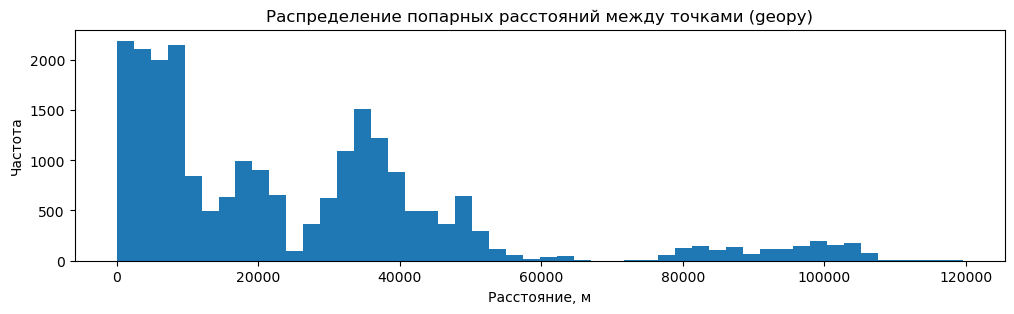

In [17]:
analyze_spatial(df_0_dist)

In [18]:
draw_map(df_0, clusters=False)

Видим очень большой разброс точек: до 120 км. 

При этом в самых отдаленных городах небольшое число точек: в Арзамасе 5, в Гороховце 4, в Володарске 4.

### 2.2.2 Пространственный анализ точек для 1 менеджера.

In [19]:
df_1_dist = compute_geo_distance_df(df_1, id_col='point_id')
display(df_1_dist.head().round())

Вычисление расстояний: 100%|█████████████████████████████████████████████████████████| 206/206 [00:02<00:00, 69.57it/s]


,ID6,ID7,ID8,ID9,ID10,ID11,ID12,ID13,ID14,ID15,...,ID423,ID424,ID425,ID426,ID427,ID428,ID429,ID430,ID431,ID432
ID6,0.0,26252.0,4442.0,26784.0,29933.0,1790.0,7915.0,688.0,3966.0,26478.0,...,149262.0,148972.0,148747.0,148500.0,148938.0,148579.0,148938.0,149626.0,151808.0,152243.0
ID7,26252.0,0.0,25663.0,8296.0,3844.0,25754.0,18404.0,26832.0,22521.0,922.0,...,137159.0,136859.0,136677.0,136604.0,136998.0,136741.0,137123.0,137708.0,139955.0,140217.0
ID8,4442.0,25663.0,0.0,27567.0,29124.0,6052.0,7733.0,4955.0,6250.0,25736.0,...,152463.0,152171.0,151951.0,151726.0,152158.0,151812.0,152175.0,152851.0,155044.0,155458.0
ID9,26784.0,8296.0,27567.0,0.0,10428.0,25773.0,19834.0,27224.0,22818.0,9210.0,...,129894.0,129596.0,129405.0,129300.0,129703.0,129427.0,129806.0,130411.0,132650.0,132944.0
ID10,29933.0,3844.0,29124.0,10428.0,0.0,29497.0,22045.0,30527.0,26257.0,3459.0,...,136889.0,136589.0,136415.0,136371.0,136757.0,136518.0,136903.0,137469.0,139721.0,139953.0



Статистика расстояний для менеджера 2:
  Среднее: 41496 м
  Медиана: 5916 м
  Минимум: 26 м
  Максимум: 164143 м


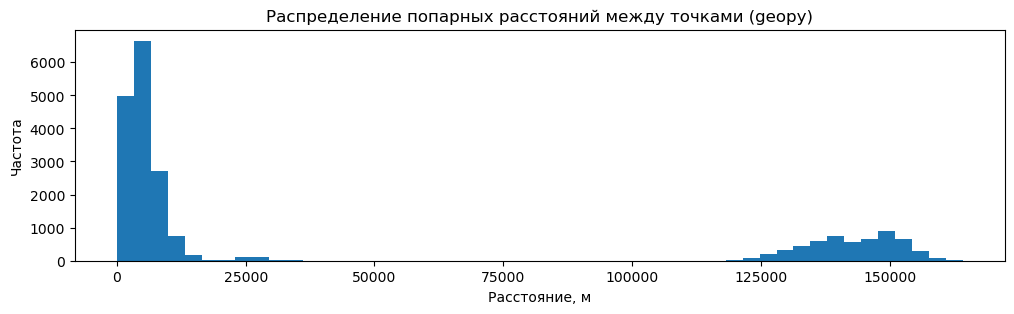

In [20]:
analyze_spatial(df_1_dist)

In [21]:
draw_map(df_1, clusters=False)

У 1 менеджера также наблюдается большой разброс точек, и также есть города с совсем маленьким числом визитов, например, Кулебаки (2 точки).

### 2.2.3 Пространственный анализ точек для 2 менеджера.

In [22]:
df_2_dist = compute_geo_distance_df(df_2, id_col='point_id')
display(df_2_dist.head().round())

Вычисление расстояний: 100%|█████████████████████████████████████████████████████████| 212/212 [00:02<00:00, 70.71it/s]


,ID38,ID39,ID40,ID41,ID42,ID43,ID44,ID45,ID46,ID47,...,ID624,ID625,ID626,ID627,ID628,ID629,ID630,ID631,ID632,ID633
ID38,0.0,3255.0,3470.0,5690.0,982.0,4338.0,2794.0,665.0,2579.0,4468.0,...,115533.0,115156.0,114926.0,116139.0,116726.0,115555.0,119968.0,120932.0,122174.0,118353.0
ID39,3255.0,0.0,1933.0,4814.0,2389.0,1232.0,1165.0,3584.0,1217.0,1381.0,...,115573.0,115205.0,115014.0,116271.0,116838.0,115646.0,119980.0,120937.0,122169.0,118389.0
ID40,3470.0,1933.0,0.0,2912.0,2506.0,1848.0,968.0,4049.0,1122.0,1878.0,...,113664.0,113295.0,113101.0,114354.0,114922.0,113732.0,118074.0,119032.0,120265.0,116480.0
ID41,5690.0,4814.0,2912.0,0.0,4906.0,4317.0,3857.0,6350.0,3971.0,4263.0,...,110760.0,110392.0,110200.0,111457.0,112023.0,110832.0,115168.0,116125.0,117358.0,113576.0
ID42,982.0,2389.0,2506.0,4906.0,0.0,3398.0,1814.0,1545.0,1600.0,3522.0,...,115139.0,114765.0,114546.0,115771.0,116353.0,115175.0,119567.0,120529.0,121769.0,117958.0



Статистика расстояний для менеджера 2:
  Среднее: 36079 м
  Медиана: 14861 м
  Минимум: 37 м
  Максимум: 193360 м


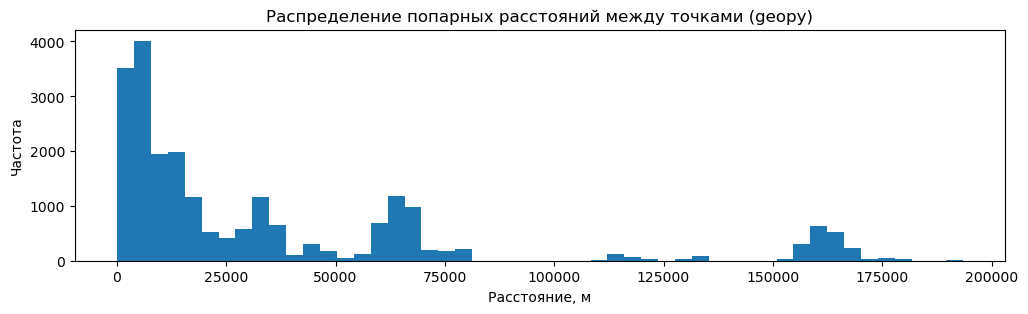

In [23]:
analyze_spatial(df_2_dist)

In [24]:
draw_map(df_2, clusters=False)

У 2 менеджера тоже наблюдаеются отдаленные кластеры, но в них больше 10 точек.

## 2.3 Матрица расстояний по дорогам

Для реализации алгоритмов кластеризации DBSCAN и иерархической кластеризации была построена матрица попарных расстояний между географическими точками.

В отличие от евклидова расстояния, вычисления выполнялись с учётом реальной дорожной сети, что позволило получить метрику, соответствующую фактическим маршрутам передвижения.

**Исходные данные и подготовка графа.**

С открытого геопортала  https://geo2day.com был загружен файл карты Нижегородской области в формате PBF (OpenStreetMap). Далее с использованием утилиты osm2pgsql данные были импортированы и преобразованы в графовую структуру, сохранённую в формате PKL. В результате получен файл nizhny_graph.pkl, содержащий объект G — ориентированный граф дорожной сети (тип networkx.DiGraph).

В данном графе:

•	вершины соответствуют перекрёсткам, транспортным развязкам и характерным точкам дорожной сети;

•	рёбра моделируют участки дорог и содержат атрибут 'length', задающий протяжённость сегмента в метрах.

**Вычислительная реализация.**

В связи с высокой ресурсоёмкостью расчётов (попарное расстояние для большого числа точек по реальной дорожной сети) все вычислительные процедуры были выполнены на платформе Kaggle.

**Привязка точек к дорожной сети.**

Первым этапом обработки являлась операция map-matching — приведение исходных географических координат к узлам графа. Для каждой точки определялся ближайший узел графа (перекрёсток или ближайшая точка на ребре) с целью последующего вычисления кратчайших путей. Соответствующий фрагмент программного кода представлен ниже.


**Вычисление матрицы попарных расстояний**

На втором этапе для отобранных узлов дорожного графа рассчитывалась матрица попарных кратчайших расстояний с учётом реальной дорожной сети.

**Подготовка графа.**

Поскольку дорожная сеть допускает движение в обоих направлениях, исходный ориентированный граф G был преобразован в неориентированный с помощью метода G.to_undirected(). Это позволило корректно моделировать двустороннее движение по всем рёбрам графа.

**Определение целевых узлов.**

Из заранее подготовленного файла valid_nodes.npy загружался массив valid_nodes, содержащий идентификаторы узлов графа, для которых требовалось вычислить попарные расстояния. Данный набор узлов соответствует точкам, прошедшим этап привязки к дорожной сети (map-matching).

**Алгоритм построения матрицы расстояний.**

Реализованная функция выполняет следующие шаги:

1.	Инициализируется квадратная матрица dist_matrix размером n × n (где n — число узлов в valid_nodes), все элементы которой заполняются значением np.inf (бесконечность) как индикатор недостижимости.

2.	Для каждого узла i из списка valid_nodes последовательно запускается алгоритм Дейкстры (single_source_dijkstra_path_length), вычисляющий кратчайшие пути от источника i до всех остальных узлов графа. В качестве веса рёбер используется атрибут 'length' (длина сегмента в метрах).

3.	Для каждого достижимого узла j (т.е. когда путь существует) полученное расстояние записывается в ячейку dist_matrix[i, j].

В итоге формируется симметричная (для неориентированного графа) матрица, где элемент [i, j] соответствует длине кратчайшего маршрута по дорогам между узлом i и узлом j.

Финальная матрица преобразуется в формат pandas.DataFrame и сохраняется в CSV-файл с именем distance_matrix_undirected.csv для последующего использования в процедурах кластеризации.



# 3. Кластеризация географических точек

Для подбора наиболее оптимального алгоритма были испробованы 3 метода кластеризации:

1. KMeans (по координатам и по матрице дорожных расстояний)

2. GBSCAN (по матрице дорожных расстояний)

3. Иерархическая (по координатам и по матрице дорожных расстояний)

Приведем результаты кластеризации по разным методам для 0 менеджера.

# 3.1 KMeans

Метод KMeans относится к центроидным алгоритмам и требует априорного задания числа кластеров k. 

**Подход 1. Кластеризация по географическим координатам**

В первом подходе в качестве входных данных использовались непосредственно географические координаты точек (широта и долгота). Выбор оптимального числа кластеров осуществлялся комбинированным методом, сочетающим статистический критерий и бизнес-ограничение.

1. Автоматический выбор k по силуэту.

Для диапазона значений k от 2 до 20 (с учётом ограничения по числу объектов) вычислялся коэффициент силуэта (silhouette_score) — метрика, оценивающая компактность и разделимость кластеров. Оптимальным выбиралось значение k, максимизирующее данный показатель.

2. Корректировка с учётом бизнес-ограничения.

Поскольку максимально допустимое число точек в одном кластере не должно превышать 12, вводилось дополнительное условие:
optimal_k = ceil(общее_число_точек / 12).

Итоговое значение k определялось как максимум из двух оценок — статистической (best_k) и бизнес-ограничения (optimal_k). Это позволило избежать как излишнего дробления, так и чрезмерного укрупнения кластеров.

С выбранным final_k выполнялась кластеризация методом K-means, после чего для каждой точки определялась метка кластера. Результаты визуализировались на карте с цветовой дифференциацией кластеров, а также выводилась статистика распределения точек по кластерам

In [25]:
df_0 = df[df['manager'] == 0].copy()

# Координаты
X = df_0[['lat', 'lon']].values

# Автовыбор k (силуэт)
max_k = min(20, len(df_0)-1)
sil_scores = []
K_range = range(2, max_k+1)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    labels = kmeans.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))
best_k = K_range[np.argmax(sil_scores)]

# Бизнес-ограничение
max_points = 12
optimal_k = int(np.ceil(len(df_0) / max_points))
final_k = max(best_k, optimal_k)
print(f"Итоговое k: {final_k}")

# Кластеризация
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df_0['cluster'] = kmeans.fit_predict(X)

# Статистика
cluster_counts = df_0['cluster'].value_counts().sort_index()
stats_df = pd.DataFrame({
    'Номер кластера': cluster_counts.index,
    'Количество точек': cluster_counts.values
})
print(stats_df.to_string(index=False))

draw_map(df_0, clusters=True)

Итоговое k: 18
 Номер кластера  Количество точек
              0                14
              1                17
              2                17
              3                 5
              4                 4
              5                18
              6                14
              7                 4
              8                12
              9                13
             10                 3
             11                 8
             12                18
             13                 4
             14                22
             15                24
             16                 9
             17                 9


**Подход 2. Кластеризация на основе дорожных расстояний**

Во втором подходе учитывалась реальная связность точек через дорожную сеть, что позволяет формировать кластеры с учётом фактической транспортной доступности, а не только географической близости.

Этапы реализации:

1. Загрузка матрицы расстояний из distance_matrix_undirected.csv

2. Извлечение подматрицы для менеджера 0

3. Многомерное шкалирование (MDS)

Поскольку алгоритм K-means требует входных данных в евклидовом пространстве, а матрица расстояний не является евклидовой, применялось метрическое многомерное шкалирование (MDS). Метод позволяет спроецировать точки из пространства попарных расстояний в двумерное евклидово пространство с минимальными искажениями исходных соотношений.

4. Кластеризация
   
На полученные двумерные координаты (coords_0_2d) накладывался алгоритм K-means с числом кластеров, равным final_k (выбранным в первом подходе для сохранения сопоставимости результатов).

In [26]:
dist_matrix = pd.read_csv('distance_matrix_undirected.csv', index_col=0)

In [27]:
# Получаем индексы (позиции) точек менеджера 0
indices_0 = df_0.index.tolist()  
print(f"Индексы точек менеджера 0: {indices_0[:5]}...")

# Извлекаем подматрицу по индексам
dist_matrix_0 = dist_matrix.iloc[indices_0, indices_0]

print(f"\n Подматрица для менеджера 0: {dist_matrix_0.shape}")

Индексы точек менеджера 0: [0, 1, 2, 3, 4]...

 Подматрица для менеджера 0: (215, 215)


In [28]:
display(dist_matrix_0.head())

,0,1,2,3,4,48,49,50,51,52,...,248,249,250,251,252,253,254,255,256,257
0,0.000,2022.355,1021.185,7479.836,3215.656,111924.514,111572.165,110214.572,110083.485,111266.219,...,112864.868,111533.810,111146.162,111589.001,110082.946,111102.371,110100.419,110042.647,112260.908,111827.572
1,2022.355,0.000,2425.518,8887.904,3710.462,113352.084,112999.735,111642.142,111511.055,112693.789,...,114292.438,112961.380,112573.732,113016.571,111510.516,112529.941,111527.989,111470.217,113688.478,113255.142
2,1021.185,2425.518,0.000,6986.139,2194.471,111430.817,111078.468,109720.875,109589.788,110772.522,...,112371.171,111040.113,110652.465,111095.304,109589.249,110608.674,109606.722,109548.950,111767.211,111333.875
3,7479.836,8887.904,6986.139,0.000,5795.093,108446.860,108094.511,106736.918,106605.831,107788.565,...,109387.214,108056.156,107668.508,108111.347,106605.292,107624.717,106622.765,106564.993,108783.254,108349.918
4,3215.656,3710.462,2194.471,5795.093,0.000,110404.776,110052.427,108694.834,108563.747,109746.481,...,111345.130,110014.072,109626.424,110069.263,108563.208,109582.633,108580.681,108522.909,110741.170,110307.834


In [29]:
# Проецируем расстояния в 2D пространство
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
coords_0_2d = mds.fit_transform(dist_matrix_0)
kmeans = KMeans(n_clusters=optimal_k, random_state=RANDOM_SEED, n_init=10)
cluster_labels = kmeans.fit_predict(coords_0_2d)

C:\Users\MSI\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


In [30]:
df_0['cluster'] = cluster_labels
# Статистика
cluster_counts = df_0['cluster'].value_counts().sort_index()
stats_df = pd.DataFrame({
    'Номер кластера': cluster_counts.index,
    'Количество точек': cluster_counts.values
})
print(stats_df.to_string(index=False))
draw_map(df_0, clusters=True)

 Номер кластера  Количество точек
              0                26
              1                12
              2                 5
              3                 4
              4                23
              5                18
              6                 4
              7                 7
              8                12
              9                 3
             10                13
             11                 4
             12                 9
             13                12
             14                17
             15                16
             16                16
             17                14


Вывод:

В целом KMeans справился с задачей, за исключением Дзержинска, где точки 130 и 158 - единственные в городе находящиеся по другую сторону от железной дороги, оказались в разных кластерах. 


# 3.2 DBSCAN

**Density-Based Spatial Clustering of Applications with Noise**

Данный метод обладает возможностями:

- выявлять кластеры произвольной формы;

- автоматически определять количество кластеров на основе плотности данных (в отличие от KMeans);

- маркировать выбросы (точки, не принадлежащие ни одному кластеру) как шум.

**Параметры алгоритма**

В исходной конфигурации использовались следующие параметры:

1. eps – радиус окрестности точки (в метрах), определяющий максимальное расстояние, при котором соседние точки считаются принадлежащими одному кластеру.

В качестве eps был перебран ряд значений [500, 600, 700, 800, 900, 1000, 1100, 1200, 1300], для каждого рассчитано число кластеров и число шумных точек.

2. min_samples – минимальное количество точек в окрестности (включая саму точку), необходимое для формирования ядра кластера

Установлено значение min_samples = 2, что позволяет объединять даже пары близкорасположенных точек.

Кластеризация выполнялась с использованием предварительно вычисленной **матрицы расстояний по дорогам** (metric='precomputed').

В результате для каждой точки была получена метка кластера, причём метка -1 соответствует шумовым точкам (выделены на карте красным цветом).

In [31]:
min_samples = 2  # минимальное число точек в кластере (включая саму точку)

In [32]:
eps_values = [500, 600, 700, 800, 900, 1000, 1100, 1200, 1300]
for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=2, metric='precomputed')
    labels = db.fit_predict(dist_matrix_0)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = sum(labels == -1)
    sizes = [sum(labels == i) for i in set(labels) if i != -1]
    print(f"eps={eps}: кластеров={n_clusters}, шум={n_noise}")

eps=500: кластеров=48, шум=60
eps=600: кластеров=42, шум=56
eps=700: кластеров=45, шум=43
eps=800: кластеров=42, шум=35
eps=900: кластеров=36, шум=31
eps=1000: кластеров=31, шум=24
eps=1100: кластеров=30, шум=16
eps=1200: кластеров=28, шум=13
eps=1300: кластеров=27, шум=13


Отобразим на карте кластеры при eps = 1200м.

In [33]:
dbscan = DBSCAN(eps=1200, min_samples=min_samples, metric='precomputed')
cluster_labels = dbscan.fit_predict(dist_matrix_0)
df_0['cluster'] = cluster_labels
draw_map(df_0, clusters=True)

**Вывод:**

DBSCAN показывает хорошее качество кластеризации, превосходя KMeans по точности разделения точек (на примере Дзержинска). 

Однако алгоритм порождает значительное количество шумовых объектов, которые по смыслу задачи не являются выбросами. Увеличение параметра eps снижает число шумов, но приводит к укрупнению кластеров, что усложняет последующее построение маршрутов. 


# 3.3 Иерархическая кластеризация

Особенности алгоритма:

1. отсутствие необходимости априорного задания числа кластеров — решение о количестве групп принимается на основе выбранного порога сходства;

2. наглядная визуализация — дендрограмма позволяет интерпретировать процесс объединения точек;

3. возможность анализа на разных масштабах — один и тот же результат может быть использован для получения различного числа кластеров путём изменения порога.

**Подход 1. Кластеризация по географическим координатам**

Для сохранения сопоставимости с первым подходом K-means, в качестве исходных признаков использовались географические координаты точек (lat, lon), принадлежащих менеджеру 0.

На первом этапе с помощью функции linkage из библиотеки scipy.cluster.hierarchy вычислялась матрица иерархических связей. 

В качестве метода агломерации был выбран method='average' — метод средней связи (UPGMA), при котором расстояние между кластерами определяется как среднее арифметическое попарных расстояний между всеми объектами в объединяемых кластерах. Данный метод считается устойчивым к выбросам и даёт сбалансированные дендрограммы.

В качестве меры близости использовалось евклидово расстояние metric='euclidean', что согласуется с геометрической природой координатных данных.

Для выделения дискретных групп из иерархической структуры применялась функция fcluster с критерием criterion='distance'. Этот критерий позволяет обрезать дендрограмму на заданном пороговом расстоянии t: все точки, объединившиеся на высоте, меньшей t, считаются принадлежащими одному кластеру.

Пороговое значение t подбиралось экспериментально с учётом масштаба координатной сетки (в градусах). Так как 1 градус широты/долготы соответствует примерно 111 км, значение t = 0.03 градуса приблизительно эквивалентно радиусу около 3.3 км.

In [34]:
coords = df_0[['lat', 'lon']].values
Z = linkage(coords, method='average', metric='euclidean')

# t — порог в тех же единицах, что и координаты (градусы)
t = 0.03  
df_0['cluster'] = fcluster(Z, t, criterion='distance')

cluster_counts = df_0['cluster'].value_counts().sort_index()
stats_df = pd.DataFrame({
    'Номер кластера': cluster_counts.index,
    'Количество точек': cluster_counts.values
})

print(stats_df.to_string(index=False))

 Номер кластера  Количество точек
              1                 2
              2                 2
              3                 3
              4                 1
              5                 1
              6                23
              7                 3
              8                 2
              9                10
             10                 6
             11                 3
             12                 4
             13                 4
             14                11
             15                24
             16                17
             17                28
             18                 2
             19                16
             20                 2
             21                 2
             22                14
             23                20
             24                 6
             25                 9


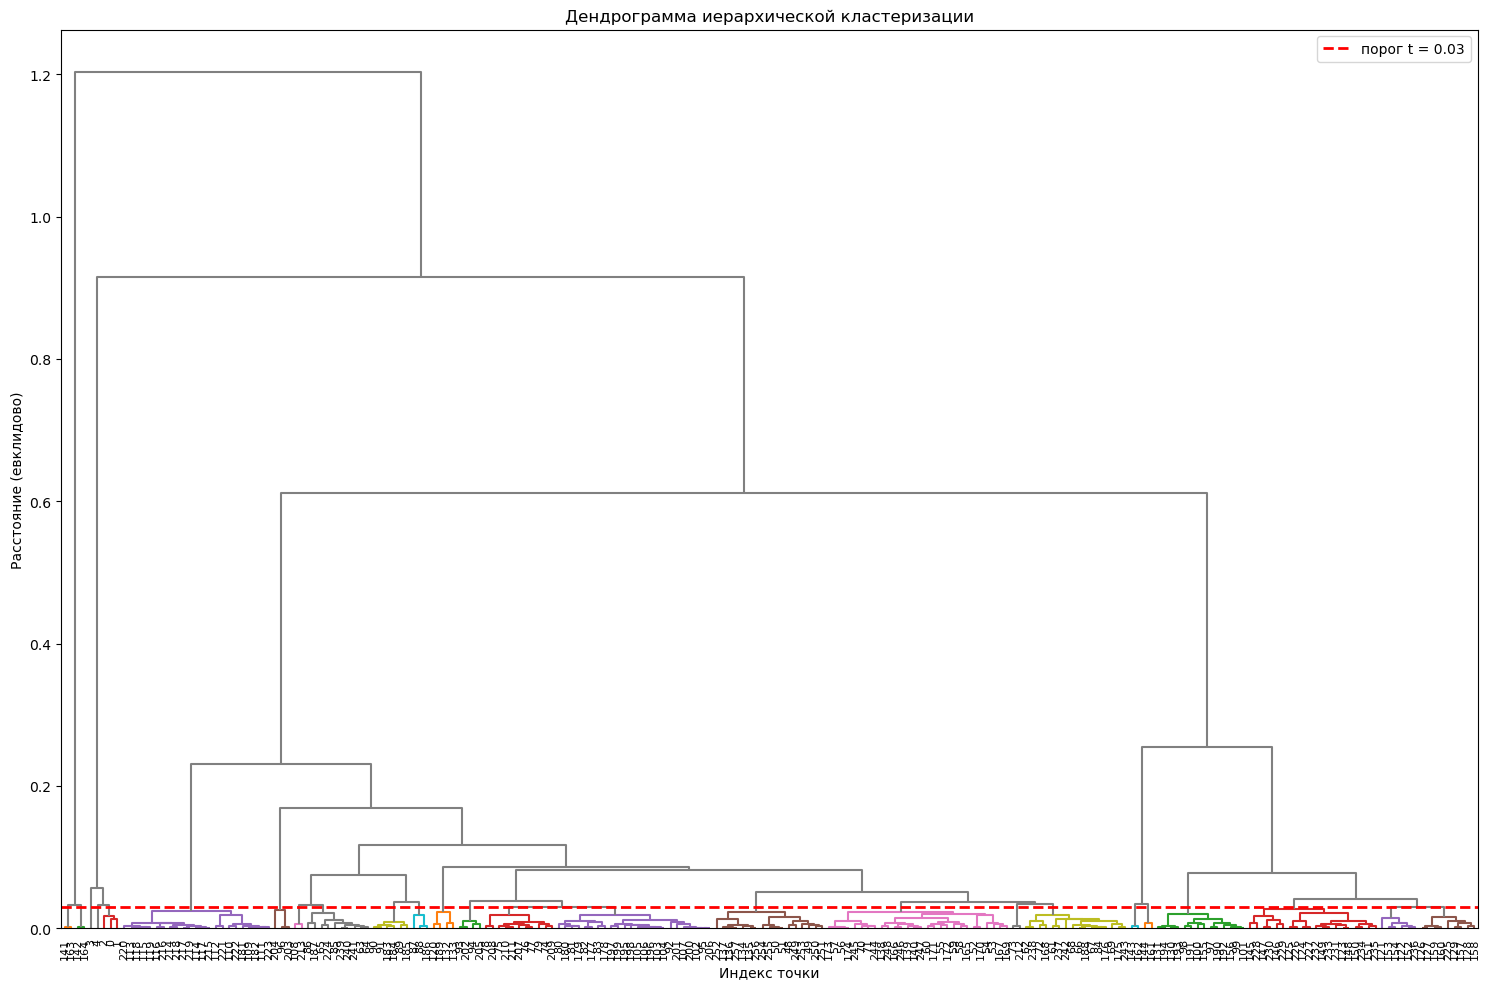

In [35]:
# Построение дендрограммы
plt.figure(figsize=(15, 10))

dendrogram(Z, 
           labels=df_0.index.tolist(),  
           leaf_rotation=90,            
           leaf_font_size=8,            
           color_threshold=0.03,        
           above_threshold_color='gray'
          )
# Добавление горизонтальной линии на уровне порога t
plt.axhline(y=0.03, color='red', linestyle='--', linewidth=2, label=f'порог t = 0.03')

plt.xlabel('Индекс точки')
plt.ylabel('Расстояние (евклидово)')
plt.title('Дендрограмма иерархической кластеризации')
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
draw_map(df_0, clusters=True)

**Подход 2. Иерархическая кластеризация на основе матрицы дорожных расстояний**

Поскольку функция linkage из библиотеки scipy.cluster.hierarchy ожидает на вход сжатый (condensed) формат расстояний, полная матрица dist_matrix_0 была преобразована с помощью функции squareform.

В качестве метода объединения, как и в первом подходе,  выбран average (UPGMA).

Для выделения дискретных групп также использовалась функция fcluster с критерием criterion='distance'.

Первоначальная попытка с порогом t = 700 метров (по аналогии с параметром eps в DBSCAN) привела к образованию 103 кластеров, что свидетельствует о чрезмерном дроблении данных. Причина заключается в том, что в иерархической кластеризации порог t определяет максимальное расстояние между объединяемыми кластерами, а не радиус окрестности отдельной точки, как в DBSCAN. Следовательно, для получения сопоставимых результатов требуются бо́льшие значения порога.

Для выбора оптимального значения t был проведён перебор в диапазоне от 1000 до 10000 метров с шагом 1000 метров, в итоге эмпирически подобрано значение t = 4000, которое дает 19 кластеров - не слишком много и не слишком мало.

In [37]:
# Преобразование полной матрицы в компактный формат
dist_condensed = squareform(dist_matrix_0, checks=False)

# Использование предварительно вычисленной матрицы расстояний
Z = linkage(dist_condensed, method='average', metric='precomputed')

In [38]:
t_values = range(1000, 11000, 1000)

for t in t_values:
    df_0[f'cluster_{t}'] = fcluster(Z, t, criterion='distance')
    n_clusters = len(set(df_0[f'cluster_{t}']))
    print(f"t={t}м: кластеров={n_clusters}")

columns_to_drop = [f'cluster_{t}' for t in t_values]
df_0.drop(columns=columns_to_drop, inplace=True)

t=1000м: кластеров=87
t=2000м: кластеров=45
t=3000м: кластеров=31
t=4000м: кластеров=19
t=5000м: кластеров=15
t=6000м: кластеров=13
t=7000м: кластеров=12
t=8000м: кластеров=10
t=9000м: кластеров=9
t=10000м: кластеров=8


In [39]:
# Порог t в метрах 
t = 4000  
df_0['cluster'] = fcluster(Z, t, criterion='distance')

cluster_counts = df_0['cluster'].value_counts().sort_index()
stats_df = pd.DataFrame({
    'Номер кластера': cluster_counts.index,
    'Количество точек': cluster_counts.values
})
print(stats_df.to_string(index=False))
draw_map(df_0, clusters=True)

 Номер кластера  Количество точек
              1                 4
              2                 1
              3                 4
              4                 4
              5                31
              6                 4
              7                13
              8                 1
              9                23
             10                 6
             11                 3
             12                 4
             13                 2
             14                10
             15                 2
             16                31
             17                30
             18                 3
             19                39


**Вывод по результатам кластеризации:**


Иерархическая кластеризация на основе матрицы дорожных расстояний показала высокую эффективность.

 На примере Дзержинска алгоритм корректно разделил точки, находящиеся по разные стороны от железной дороги, что подтверждает его чувствительность к реальным препятствиям дорожной сети

 В отличие от DBSCAN, данный метод не создаёт шумовых точек (все объекты получают метку кластера), а также не требует априорного задания числа кластеров, как KMeans.

 Благодаря этим свойствам, иерархическая кластеризация выбрана в качестве основного инструмента на первом этапе — присвоения точкам номеров кластеров для последующего планирования маршрутов.


# 4. Алгоритм построения маршрутов

**1. Исходные данные и ограничения**

Без ограничения общности приведем решение для менеджера 0.

За отправную точку маршрутов возьмем точку  с координатами: широта: NN_LON = 56.326887,  долгота: NN_LAT = 44.005986 (г. Нижний Новгород). 

Назовем ее для удобства Базой.

**2. Расчет расстояний до Базы**
   
Для каждой точки вычисляется длина пути от Базы по неориентированному графу дорожной сети (не по прямой) с использованием алгоритма Дейкстры (single_source_dijkstra_path_length).

Расстояния переводятся в километры.

**3. Отсечение кластеров дальше 150 км**
   
Если общее число визитов превышает target (22 * 12 = 264), выполняется фильтрация по территориальному принципу: для каждого кластера вычисляется среднее расстояние до Базы.

Кластеры, у которых среднее расстояние до базы превышает 150 км, исключаются из рассмотрения.

**4. Последовательное удаление самых дальних кластеров**

Если после фильтрации по 150 км число визитов всё ещё превышает target, запускается итеративное удаление кластеров: кластеры сортируются по убыванию среднего расстояния до Базы. Самые дальние удаляются  до тех пор, пока общее число визитов не станет ≤ target.

Таким образом, оставшийся набор точек гарантированно помещается в плановое число визитов.

После удаления части кластеров выполняется их сквозная перенумерация (0, 1, 2, …), чтобы избежать разрывов в идентификаторах и упростить дальнейшую обработку.

**5. Разбиение крупных кластеров**

Разбиваем кластеры на подкластеры таким образом, чтобы суммарное число визитов в каждом подкластере не превышало дневную ёмкость (12 визитов).

Все точки группируются по текущим кластерам (day_cluster).

Далее применяется жадная сортировка — внутри каждого кластера точки сортируются по убыванию n_visits (сначала точки с большим числом визитов). Это позволяет минимизировать количество подкластеров.

Формирование подкластеров — точки последовательно добавляются в текущий подкластер до тех пор, пока суммарное число визитов не превысит лимит (12). 

Как только добавление очередной точки приводит к переполнению, текущий подкластер сохраняется как новый кластер и начинается формирование следующего подкластера.

После обработки всех точек последний подкластер также сохраняется.

**6. Формирование визитов и назначение дней**

Для каждой точки создаётся n_visits отдельных визитов (с учётом кратности посещений).
Каждый визит привязывается к своему кластеру и номеру визита в рамках точки.

Далее выполняется жадное распределение по дням:

Крупные группы в приоритете — группы визитов (кластер, номер_визита) сортируются по убыванию размера, чтобы сложные для размещения группы обрабатывались первыми.

Для каждой группы ищется день, где:

- достаточно свободных мест (≤ 12 визитов в день);

- нет конфликтов по точкам (одна точка не может иметь два визита в один день);

- предпочтение отдаётся дням, где уже есть визиты из этого же кластера (для минимизации разрывов маршрутов).

Если кластер не влезает целиком, применяется поштучный fallback — визиты распределяются по свободным дням с учётом:

дневной ёмкости (12 визитов);

запрета на посещение одной точки в один день (даже при нескольких визитах).

Если для какого-то визита не находится места, выбрасывается ошибка (это сигнализирует о необходимости увеличить число дней или уменьшить число визитов).

**7. Построение маршрутов (TSP)**

Для каждого дня строится оптимальный порядок объезда точек с помощью жадного алгоритма.

Старт происходит от Базы. На каждом шаге выбирается ближайшая непосещённая точка:

на первом шаге — по расстоянию от Базы;

на последующих — по матрице попарных дорожных расстояний между точками.

Маршрут заканчивается после посещения всех точек, назначенных на этот день.

Используется заранее подготовленная подматрица расстояний только для оставшихся после фильтрации точек, что ускоряет вычисления.

**8. Формирование итоговой таблицы**

Для каждого визита формируется запись, содержащая:

**point_id** — идентификатор точки;

**visit_day** — номер дня (от 1 до 22);

**cluster_id** — идентификатор кластера (после всех разбиений);

**order_in_route** — порядковый номер посещения в маршруте дня.

Результат сохраняется в CSV-файл manager0_schedule.csv.

На всех этапах алгоритм выводит диагностическую информацию:

•	количество точек и визитов до и после фильтрации;

•	загрузка по дням;

•	количество свободных слотов;

•	максимальный размер группы после разбиения.


**9. Отображение всех маршрутов на карте, а также отрисовка маршрутов по отдельным дням**

## 4.1 Исходные данные

In [40]:
# Исходные данные
NN_LAT, NN_LON = 56.326887, 44.005986

df_0['orig_idx'] = df_0.index.astype(int)   # запоминаем позицию в исходной матрице

target = DAYS * MAX_VISITS_PER_DAY

print(f"Точек менеджера 0 до фильтрации: {len(df_0)}")
print(f"Визитов менеджера 0 до фильтрации: {df_0['n_visits'].sum()}")
print(f"Максимально возможное число визитов: {target}")


Точек менеджера 0 до фильтрации: 215
Визитов менеджера 0 до фильтрации: 405
Максимально возможное число визитов: 264


## 4.2 Расстояния до Базы

In [41]:
# Расчет расстояний до Базы
with open('nizhny_graph_undirected.pkl', 'rb') as f:
    G_undirected = pickle.load(f)

valid_nodes = np.load('valid_nodes.npy', allow_pickle=True)

nn_node = ox.distance.nearest_nodes(G_undirected, NN_LON, NN_LAT)
distances_from_nn = nx.single_source_dijkstra_path_length(G_undirected, nn_node, weight='length')

# км для каждой точки (порядок совпадает с valid_nodes, а тот — с df)
nn_dists_km = np.array([
    distances_from_nn.get(node, np.inf) / 1000.0 
    for node in valid_nodes
])

np.save('nn_dists_km.npy', nn_dists_km)

df_0['dist_from_nn_km'] = nn_dists_km[df_0.index]

In [42]:
display(df_0.head())

,point_id,manager,lat,lon,n_visits,cluster,orig_idx,dist_from_nn_km
0,ID1,0,55.371884,43.846878,1,1,0,114.253465
1,ID2,0,55.358381,43.845061,1,1,1,115.681035
2,ID3,0,55.374786,43.832983,1,1,2,113.759768
3,ID4,0,55.423430,43.813190,1,2,3,110.775811
4,ID5,0,55.381287,43.811452,1,1,4,112.733727


## 4.3 Удаление дальних кластеров 

In [43]:
# Фильтрация кластеров дальше 150 км при превышении числа визитов заданного значения target
if df_0['n_visits'].sum() > target:
    cluster_dist = df_0.groupby(['manager', 'cluster'])['dist_from_nn_km'].mean().reset_index()
    valid_clusters = cluster_dist[cluster_dist['dist_from_nn_km'] <= 150][['manager', 'cluster']]
    
    for col in ['manager', 'cluster']:
        df_0[col] = df_0[col].astype('int64')
        valid_clusters[col] = valid_clusters[col].astype('int64')
    
    df_0 = df_0.merge(valid_clusters, on=['manager', 'cluster'])
    print(f"После фильтра 150 км: {len(df_0)} точек, {df_0['n_visits'].sum()} визитов")
else:
    print('Фильтрация не требуется')

После фильтра 150 км: 215 точек, 405 визитов


In [44]:
# Последовательное удаление самых дальних кластеров до достижения числа визитов значения target
df_0['day_cluster'] = df_0['cluster'].astype(int)#переименовываем колонку

#группируем все точки по кластерам 
#для каждого кластера считаем сред.расст.от всех точек до базы,число точек в кластере,общее число визитов
cluster_stats = df_0.groupby('day_cluster').agg(
    dist_from_nn=('dist_from_nn_km', 'mean'),
    n_points=('point_id', 'count'),
    total_visits=('n_visits', 'sum')
).reset_index().sort_values('dist_from_nn', ascending=False)#самые дальние кластеры идут первыми

current_visits = int(cluster_stats['total_visits'].sum())#текущее общее число визитов (до удаления)
clusters_to_remove = [] #список кластеров, которые мы решим удалить

#
for _, row in cluster_stats.iterrows():
    if current_visits <= target:#проверяем условие на достижения лимита визитов
        break
    clusters_to_remove.append(int(row['day_cluster']))#самый дальний кластер (первая строка в cluster_stats)
    current_visits -= int(row['total_visits'])#вычитаем его визиты из current_visits

print(f"Удаляем кластеры: {clusters_to_remove} (визитов стало: {current_visits})")

#оставляем только те точки, которых нет в списке на удаление
df_0 = df_0[~df_0['day_cluster'].isin(clusters_to_remove)].copy()

# Перенумерация кластеров подряд
unique_clusters = sorted(df_0['day_cluster'].unique())#находим все уникальные кластеры и сортируем
mapping = {old: new for new, old in enumerate(unique_clusters)}#создаём словарь замены:
df_0['day_cluster'] = df_0['day_cluster'].map(mapping)#применяем маппинг ко всем точкам

print(f"После удаления: {len(df_0)} точек, {df_0['n_visits'].sum()} визитов")

Удаляем кластеры: [1, 2, 3, 4, 6, 5, 8, 7, 9] (визитов стало: 246)
После удаления: 130 точек, 246 визитов


In [45]:
draw_map(df_0, clusters=True)

Необходимо отметить, что после удаления из работы выпали Дзержинск, Володарск, Гороховец и Кстово.

Остались только Нижний Новгород с ближайшими окрестностями. То есть мы жертвуем самыми дальними точками, чтобы сделать план визитов реалистичным. 

## 4.4 Разбиение крупных кластеров

In [46]:
display(df_0.head())

,point_id,manager,lat,lon,n_visits,cluster,orig_idx,dist_from_nn_km,day_cluster
5,ID49,0,56.308180,43.990608,2,17,48,2.576149,7
6,ID50,0,56.300042,43.997411,2,17,49,4.259096,7
7,ID51,0,56.285608,43.999561,2,17,50,6.304557,7
8,ID52,0,56.284653,43.999825,2,17,51,6.435644,7
9,ID53,0,56.290024,44.012407,2,17,52,5.319523,7


In [47]:
def split_large_clusters_by_visits(df_m, max_visits=MAX_VISITS_PER_DAY):
    """
    Разбивает кластеры так, чтобы сумма n_visits в каждом подкластере <= max_visits.
    Точки добавляются жадно: сначала крупные n_visits, потом меньшие.
    """
    result = []
    new_cl_id = 0
    
    for cl, group in df_m.groupby('day_cluster'):#группируем все точки по текущим кластерам
        # Сортируем точки по убыванию n_visits (жадно: сначала тяжёлые)
        group_sorted = group.sort_values('n_visits', ascending=False)
        
        current_sub = []#список точек в текущем подкластере
        current_visits = 0 #суммарное число визитов в текущем подкластере
        
        for _, row in group_sorted.iterrows():
            # Если добавление этой точки перевалит за 12 визитов — начинаем новый подкластер
            if current_visits + row['n_visits'] > max_visits and len(current_sub) > 0:
                g = pd.DataFrame(current_sub)
                g['day_cluster'] = new_cl_id
                result.append(g)
                new_cl_id += 1
                
                current_sub = []
                current_visits = 0
            
            current_sub.append(row)
            current_visits += row['n_visits']
        
        # сохраняем последний подкластер
        if current_sub:
            g = pd.DataFrame(current_sub)
            g['day_cluster'] = new_cl_id
            result.append(g)
            new_cl_id += 1
    
    return pd.concat(result, ignore_index=True)


# --- Запуск ---
df_0 = split_large_clusters_by_visits(df_0, max_visits=12)

# Проверка
test_visits = []
for _, row in df_0.iterrows():
    for v in range(1, row['n_visits'] + 1):
        test_visits.append({'day_cluster': row['day_cluster'], 'visit_num': v})
group_sizes = pd.DataFrame(test_visits).groupby(['day_cluster', 'visit_num']).size()
print(f"После разбиения: макс группа = {group_sizes.max()}, всего групп = {len(group_sizes)}")

После разбиения: макс группа = 7, всего групп = 50


In [48]:
display(df_0.head())

,point_id,manager,lat,lon,n_visits,cluster,orig_idx,dist_from_nn_km,day_cluster
0,ID90,0,56.196079,44.122955,2,10,89,18.027491,0
1,ID91,0,56.189183,44.124415,2,10,90,19.175919,0
2,ID92,0,56.188510,44.122524,2,10,91,19.175919,0
3,ID184,0,56.192608,44.122165,2,10,183,18.387163,0
4,ID185,0,56.190502,44.119771,2,10,184,18.594269,0


In [49]:
# Подматрица расстояний для оставшихся точек
remaining_indices = df_0['orig_idx'].tolist()

dist_matrix_0 = dist_matrix.iloc[remaining_indices, remaining_indices].values

# Маппинги для TSP
pid_to_local = {pid: i for i, pid in enumerate(df_0['point_id'])}
local_to_pid = {i: pid for i, pid in enumerate(df_0['point_id'])}

# Расстояния от Базы (в км)
nn_dist_map = df_0.set_index('point_id')['dist_from_nn_km'].to_dict()

print(f"Подматрица: {dist_matrix_0.shape}")

Подматрица: (130, 130)


## 4.5 Формирование таблицы визитов и дней

In [50]:
# Формирование визитов и назначение дней
visits = []
#разворачиваем каждую точку в n_visits отдельных визитов, все остальные атрибуты точки сохраняются
for _, row in df_0.iterrows():
    for v in range(1, row['n_visits'] + 1):
        visits.append({
            'point_id': row['point_id'],
            'manager': row['manager'],
            'lat': row['lat'],
            'lon': row['lon'],
            'day_cluster': row['day_cluster'],
            'visit_num': v
        })
visits_df = pd.DataFrame(visits)

#
def assign_days(visits_df, manager_id=0, n_days=DAYS, capacity=MAX_VISITS_PER_DAY):
    mdf = visits_df[visits_df['manager'] == manager_id].copy() #копия данных (чтобы не менять оригинал)
    schedule = [[] for _ in range(n_days)] #список из  n_days пустых списков (по одному на день)
    day_load = [0] * n_days #список из  n_days чисел, загрузка каждого дня
    point_days = {}  #словарь: для каждой точки запоминаем, в какие дни она уже назначена
    
    # Крупные группы в приоритете
    groups = mdf.groupby(['day_cluster', 'visit_num']) #группируем визиты по парам 
    group_info = groups.size().reset_index(name='size').sort_values('size', ascending=False)#считаем размер каждой группы (сколько визитов в ней)
                                                                                            #сортируем по убыванию размера
    
    for _, g_row in group_info.iterrows():#берём очередную группу (самую крупную из оставшихся)
        cl, vn = int(g_row['day_cluster']), int(g_row['visit_num'])
        gdf = mdf[(mdf['day_cluster'] == cl) & (mdf['visit_num'] == vn)]#извлекаем все визиты этой группы в gdf
        
        # --- Попытка 1: весь кластер в один день ---
        best_day = None
        best_score = float('inf')
        for day in range(n_days):
            # Проверка 1: хватает ли места?
            if day_load[day] + len(gdf) > capacity:
                continue
            # Проверка 2: Нет ли конфликта по точкам? (запрещаем посещение одной точки в один день)
            conflict = any(
                day in point_days.get(r['point_id'], set())
                for _, r in gdf.iterrows()
            )
            if conflict:
                continue
                
            #расчёт оценки для этого дня, чем меньше score, тем лучше
            same_cluster = sum(1 for p in schedule[day] if p['day_cluster'] == cl)
            score = day_load[day] - same_cluster * 10 # 10 - бонус за то, что в этом дне уже есть визиты из этого же кластера
            #выбираем день с минимальной оценкой
            if score < best_score:
                best_score = score
                best_day = day

        #размещение группы (если нашли день)
        if best_day is not None:
            for _, r in gdf.iterrows():
                schedule[best_day].append(r.to_dict()) #добавляем все визиты группы в выбранный день
                point_days.setdefault(r['point_id'], set()).add(best_day) #запоминаем для каждой точки, что она уже занята в этот день
            day_load[best_day] += len(gdf) #обновляем загрузку дня
            continue
        
        # --- Попытка 2: поштучный fallback ---
        print(f" Группа (cl={cl}, v={vn}, n={len(gdf)}) не влезла целиком, разбиваем")
        for _, r in gdf.iterrows():
            pid = r['point_id']
            placed = False
            #ищем первый день, где есть свободное место и нет конфликта по точке
            for day in range(n_days):
                if day_load[day] + 1 > capacity:
                    continue
                if day in point_days.get(pid, set()):
                    continue
                #если нашли — размещаем
                schedule[day].append(r.to_dict())
                point_days.setdefault(pid, set()).add(day)
                day_load[day] += 1
                placed = True
                break
            if not placed:
                raise ValueError(f"Критическая нехватка места для {pid}")
    
    return schedule, day_load
    
schedule, day_load = assign_days(visits_df, manager_id=0, n_days=DAYS, capacity=MAX_VISITS_PER_DAY)
display(visits_df.head())
print(f"\nЗагрузка по дням: {day_load}")
print(f"Свободных слотов: {target - sum(day_load)}")

,point_id,manager,lat,lon,day_cluster,visit_num
0,ID90,0,56.196079,44.122955,0,1
1,ID90,0,56.196079,44.122955,0,2
2,ID91,0,56.189183,44.124415,0,1
3,ID91,0,56.189183,44.124415,0,2
4,ID92,0,56.188510,44.122524,0,1



Загрузка по дням: [11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 10, 10, 10, 11, 11, 10, 9, 10, 10]
Свободных слотов: 18


## 4.6 Построение маршрутов

In [51]:
# Построение маршрутов (TSP)
results = [] #список для сбора данных о маршрутах

for day_idx, day_visits in enumerate(schedule):
    if not day_visits:
        continue
    
    day_pids = [v['point_id'] for v in day_visits] #список ID всех точек в этом дне
    unvisited = set(day_pids) #множество непосещённых точек (начинаем со всех)
    route_pids = [] #список точек в порядке посещения (результат)
    current_pid = None  #текущая точка (где мы сейчас находимся), если None, то База 
    
    while unvisited:
        if current_pid is None:
            #выбираем ближайшую непосещенную от Базы
            nearest = min(unvisited, key=lambda pid: nn_dist_map[pid])
        else:
            #выбираем ближайшую непосещенную от текущей
            nearest = min(
                unvisited,
                key=lambda pid: dist_matrix_0[pid_to_local[current_pid]][pid_to_local[pid]]
            )
        route_pids.append(nearest) #добавляем выбранную точку в маршрут
        unvisited.remove(nearest) #удаляем её из множества непосещённых
        current_pid = nearest #ближайшая становится текущей

  
    # Сборка результата
    for order, pid in enumerate(route_pids, 1): #перебираем точки в порядке маршрута (route_pids), для каждой точки находит её cluster_id из визитов этого дня
        results.append({
            'point_id': pid,
            'visit_day': day_idx + 1,
            'cluster_id': next(v['day_cluster'] for v in day_visits if v['point_id'] == pid),#находим в списке визитов этого дня первый визит, у которого ID точки равно pid, и берем из него day_cluster
            'order_in_route': order
        })

result_df = pd.DataFrame(results)
result_df.to_csv('manager0_schedule.csv', index=False, encoding='utf-8-sig')
print(f"\nИтоговая таблица: {len(result_df)} строк")
display(result_df)


Итоговая таблица: 246 строк


,point_id,visit_day,cluster_id,order_in_route
0,ID246,1,11,1
1,ID243,1,11,2
2,ID244,1,11,3
3,ID69,1,11,4
4,ID68,1,11,5
...,...,...,...,...
241,ID105,22,23,6
242,ID95,22,23,7
243,ID94,22,23,8
244,ID109,22,3,9


Вывод таблицы посещений для произвольного дня.

In [52]:
day = 2
display(result_df[result_df['visit_day']==day])

,point_id,visit_day,cluster_id,order_in_route
11,ID200,2,19,1
12,ID198,2,19,2
13,ID178,2,19,3
14,ID196,2,18,4
15,ID197,2,18,5
16,ID199,2,19,6
17,ID201,2,18,7
18,ID180,2,18,8
19,ID181,2,18,9
20,ID75,2,18,10


## 4.7 Расчет пройденного расстояния по дням

Расчет длины маршрута по матрице расстояний и по координатам.

In [53]:
def estimate_day_distance_exact(day_df, dist_matrix_0, pid_to_local, nn_dist_map):
    """Точная оценка маршрута по матрице расстояний."""
    pids = ['BASE'] + day_df.sort_values('order_in_route')['point_id'].tolist()
    total = 0
    for i in range(len(pids) - 1):
        if pids[i] == 'BASE':
            total += nn_dist_map[pids[i+1]]
        else:
            total += dist_matrix_0[pid_to_local[pids[i]]][pid_to_local[pids[i+1]]]
    return total / 1000  # в км

def estimate_day_distance(day_df, nn_lat, nn_lon):
    """Грубая оценка длины маршрута (по прямой, для инфо-блока)."""
    coords = [[nn_lat, nn_lon]] + day_df[['lat', 'lon']].values.tolist()
    total = 0
    for i in range(len(coords) - 1):
        # грубая оценка: 1 град широты ≈ 111 км
        dy = (coords[i+1][0] - coords[i][0]) * 111
        dx = (coords[i+1][1] - coords[i][1]) * 111 * np.cos(np.radians(coords[i][0]))
        total += np.sqrt(dx**2 + dy**2)
    return total

In [54]:
def calculate_route_stats(result_df, dist_matrix_0, pid_to_local, nn_dist_map, 
                          return_to_base=False):
    """
    Расчет пройденного расстояния по дням.
    
    Parameters:
    -----------
    result_df : pd.DataFrame
        Колонки: point_id, visit_day, order_in_route
    dist_matrix_0 : np.array
        Подматрица расстояний точка-точка (в метрах)
    pid_to_local : dict
        point_id -> индекс в dist_matrix_0
    nn_dist_map : dict
        point_id -> расстояние от НН до точки (в км)
    return_to_base : bool
        Добавлять ли возврат на базу после последней точки дня
    
    Returns:
    --------
    stats_df : pd.DataFrame
        Статистика по каждому дню
    total_km : float
        Общий пробег за все дни
    """
    daily_stats = []
    
    for day in sorted(result_df['visit_day'].unique()):
        day_df = result_df[result_df['visit_day'] == day].sort_values('order_in_route')
        pids = day_df['point_id'].tolist()
        
        if len(pids) == 0:
            continue
        
        # --- Расстояние от НН до первой точки ---
        dist_from_base = nn_dist_map.get(pids[0], 0)
        
        # --- Межточечные переходы ---
        inter_point_km = 0
        for i in range(1, len(pids)):
            prev_pid = pids[i - 1]
            curr_pid = pids[i]
            dist_m = dist_matrix_0[pid_to_local[prev_pid]][pid_to_local[curr_pid]]
            inter_point_km += dist_m / 1000.0
        
        # --- Возврат на базу (опционально) ---
        return_km = 0
        if return_to_base and len(pids) > 0:
            last_pid = pids[-1]
            return_km = nn_dist_map.get(last_pid, 0)
        
        day_total = dist_from_base + inter_point_km + return_km
        
        daily_stats.append({
            'day': int(day),
            'n_points': len(pids),
            'from_base_km': round(dist_from_base, 2),
            'inter_point_km': round(inter_point_km, 2),
            'return_km': round(return_km, 2) if return_to_base else None,
            'total_km': round(day_total, 2)
        })
    
    stats_df = pd.DataFrame(daily_stats)
    total_km = stats_df['total_km'].sum()
    
    return stats_df, total_km


# --- ЗАПУСК ---
stats_df, total_km = calculate_route_stats(
    result_df, 
    dist_matrix_0, 
    pid_to_local, 
    nn_dist_map,
    return_to_base=False   # поменять на True, если менеджер возвращается на Базу
)

print(f"\n{'='*50}")
print(f"ОБЩИЙ ПРОБЕГ: {total_km:.1f} км")
print(f"{'='*50}")
print(f"\nПо дням:")
print(stats_df.to_string(index=False))

print(f"\n--- Сводка ---")
print(f"Средний пробег в день: {stats_df['total_km'].mean():.1f} км")
print(f"Минимальный день: {stats_df['total_km'].min():.1f} км (день {stats_df.loc[stats_df['total_km'].idxmin(), 'day']})")
print(f"Максимальный день: {stats_df['total_km'].max():.1f} км (день {stats_df.loc[stats_df['total_km'].idxmax(), 'day']})")


ОБЩИЙ ПРОБЕГ: 593.6 км

По дням:
 day  n_points  from_base_km  inter_point_km return_km  total_km
   1        11          1.77           29.21      None     30.98
   2        12          9.01           13.13      None     22.15
   3        12          2.54           29.96      None     32.50
   4        12          1.89           18.79      None     20.68
   5        12          1.89           18.79      None     20.68
   6        12          2.16           20.82      None     22.97
   7        12          2.16           20.82      None     22.97
   8        12          1.89           13.95      None     15.83
   9        12          1.89           13.95      None     15.83
  10        12          2.92           22.61      None     25.53
  11        12          2.92           23.29      None     26.21
  12        12          9.07           14.15      None     23.22
  13        12          2.54           21.15      None     23.68
  14        10          4.26           25.07      None  

## 4.8 Отображение маршрутов на карте

In [55]:
m = draw_map_by_days(result_df, df_0, show_routes=True)
m.save('manager0_days.html')
m  

In [56]:
nn_dist_map = df_0.set_index('point_id')['dist_from_nn_km'].to_dict()

In [62]:
# День 1
day_number=1
m1 = draw_single_day(result_df, df_0, day_number=day_number, route_color='red')
m1.save('day_1.html')
m1

In [59]:
# сохранить все 22 дня
for d in range(1, 23):
    md = draw_single_day(result_df, df_0, day_number=d, route_color='blue')
    if md:
        md.save(f'day_{d:02d}.html')

# Вывод